In [1]:
!pip install torch torchvision opencv-python matplotlib tqdm scikit-image scipy pandas

In [2]:
import os
import cv2
import glob
import torch
import numpy as np
import pandas as pd

from tqdm import tqdm
import matplotlib.pyplot as plt

In [5]:
dataset_root = r"E:\PHD Rahul Jain\Underwater\trashcan_data"

# -----------------------------------
# ONLY IMAGE FOLDERS
# -----------------------------------

target_folders = [

    "instance train",
    "instance val",

    "material train",
    "material val"
]

# -----------------------------------
# VALID EXTENSIONS
# -----------------------------------

valid_extensions = (
    ".jpg",
    ".jpeg",
    ".png"
)

# -----------------------------------
# COLLECT REAL RGB IMAGES ONLY
# -----------------------------------

image_paths = []

for folder in target_folders:

    img_folder = os.path.join(
        dataset_root,
        folder,
        "img"
    )

    if os.path.exists(img_folder):

        for file in os.listdir(img_folder):

            if file.lower().endswith(valid_extensions):

                full_path = os.path.join(
                    img_folder,
                    file
                )

                image_paths.append(full_path)

# -----------------------------------
# FINAL COUNT
# -----------------------------------

print("Total Benchmark Images:",
      len(image_paths))

Total Benchmark Images: 7212


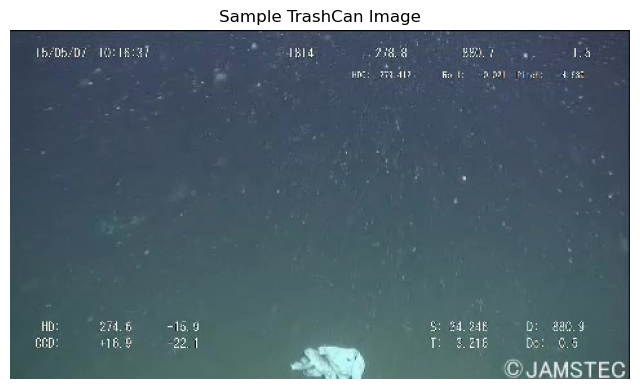

In [6]:
sample_path = image_paths[0]

img = cv2.imread(sample_path)

img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(8,6))

plt.imshow(img)

plt.title("Sample TrashCan Image")

plt.axis("off")

plt.show()

In [19]:
def adaptive_white_balance(img):

    result = img.copy().astype(np.float32)

    avg_b = np.mean(result[:,:,0])
    avg_g = np.mean(result[:,:,1])
    avg_r = np.mean(result[:,:,2])

    avg_gray = (avg_b + avg_g + avg_r) / 3

    result[:,:,0] *= (avg_gray / avg_b)
    result[:,:,1] *= (avg_gray / avg_g)
    result[:,:,2] *= (avg_gray / avg_r)

    result = np.clip(result, 0, 255)

    return result.astype(np.uint8)

In [20]:
def gamma_correction(img, gamma=1.2):

    inv_gamma = 1.0 / gamma

    table = np.array([

        ((i / 255.0) ** inv_gamma) * 255

        for i in np.arange(256)

    ]).astype("uint8")

    return cv2.LUT(img, table)

In [21]:
def guided_smoothing(img):

    smooth = cv2.bilateralFilter(

        img,

        d=5,

        sigmaColor=50,

        sigmaSpace=50
    )

    return smooth

In [22]:
import sys

sys.path.append("Models/FUnIE-GAN")

from PyTorch.nets.funiegan import GeneratorFunieGAN

print("FUnIE-GAN Imported Successfully.")

FUnIE-GAN Imported Successfully.


In [23]:
device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"
)

print("Using Device:", device)

Using Device: cpu


In [24]:
generator = GeneratorFunieGAN().to(device)

In [25]:
checkpoint_path = r"Models/FUnIE-GAN/PyTorch/models/funie_generator.pth"

generator.load_state_dict(

    torch.load(
        checkpoint_path,
        map_location=device
    )
)

generator.eval()

print("FUnIE-GAN Loaded Successfully.")

FUnIE-GAN Loaded Successfully.


In [31]:
from torchvision import transforms

transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize((256,256)),

    transforms.ToTensor(),

    
])

In [32]:
def tensor_to_image(tensor):

    img = tensor.squeeze(0).cpu().detach().numpy()

    img = np.transpose(img, (1,2,0))

    img = np.clip(img, 0, 1)

    img = (img * 255).astype(np.uint8)

    return img

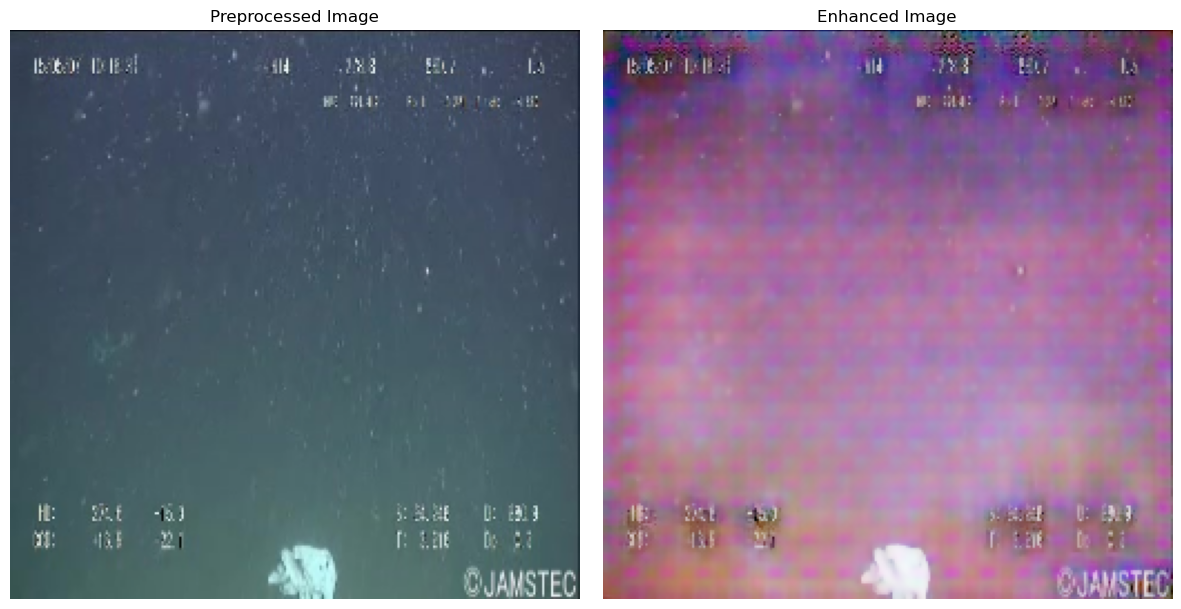

In [34]:
test_path = image_paths[0]

img = cv2.imread(test_path)

img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

# -----------------------------------
# Preprocessing
# -----------------------------------

img = cv2.resize(
    img,
    (256,256)
)

# -----------------------------------
# Tensor Conversion
# -----------------------------------

input_tensor = transform(img)

input_tensor = input_tensor.unsqueeze(0).to(device)

# -----------------------------------
# Enhancement
# -----------------------------------

with torch.no_grad():

    output = generator(input_tensor)

# -----------------------------------
# Convert Output
# -----------------------------------

enhanced = tensor_to_image(output)

enhanced = guided_smoothing(enhanced)

# -----------------------------------
# Plot
# -----------------------------------

fig, ax = plt.subplots(
    1,
    2,
    figsize=(12,6)
)

ax[0].imshow(img)

ax[0].set_title("Preprocessed Image")

ax[0].axis("off")

ax[1].imshow(enhanced)

ax[1].set_title("Enhanced Image")

ax[1].axis("off")

plt.tight_layout()

plt.show()

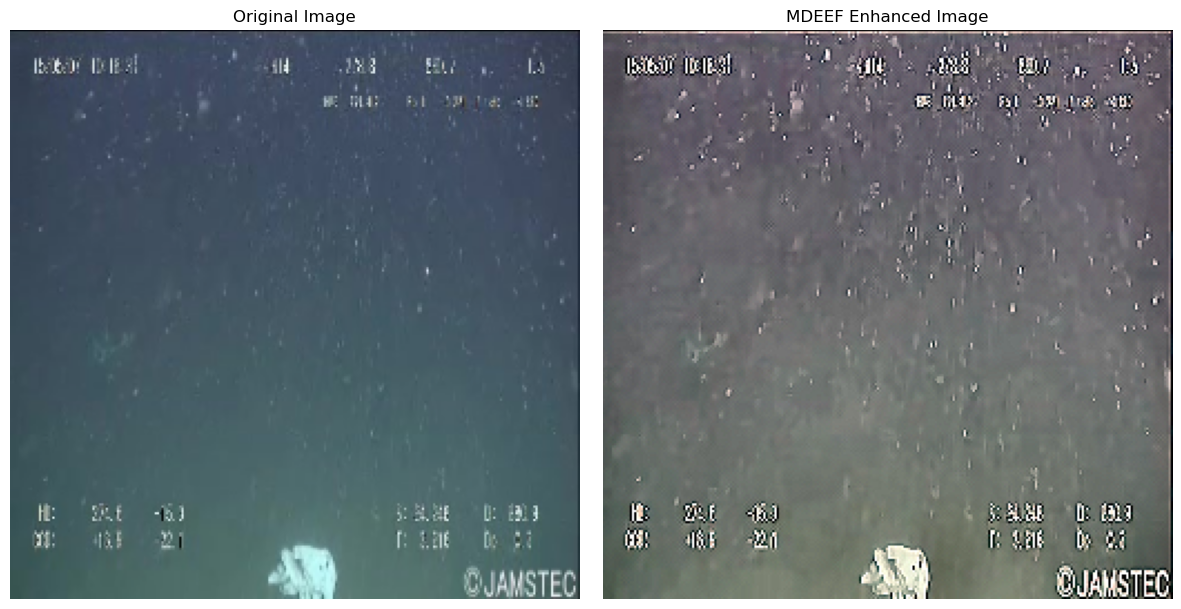

In [35]:
# -----------------------------------
# Load Sample Image
# -----------------------------------

test_path = image_paths[0]

img = cv2.imread(test_path)

img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

# -----------------------------------
# Resize
# -----------------------------------

img = cv2.resize(
    img,
    (256,256)
)

original = img.copy()

# -----------------------------------
# Gray World White Balance
# -----------------------------------

result = img.astype(np.float32)

avg_b = np.mean(result[:,:,0])
avg_g = np.mean(result[:,:,1])
avg_r = np.mean(result[:,:,2])

avg_gray = (avg_b + avg_g + avg_r) / 3

result[:,:,0] *= (avg_gray / avg_b)
result[:,:,1] *= (avg_gray / avg_g)
result[:,:,2] *= (avg_gray / avg_r)

result = np.clip(result, 0, 255)

result = result.astype(np.uint8)

# -----------------------------------
# CLAHE Enhancement
# -----------------------------------

lab = cv2.cvtColor(
    result,
    cv2.COLOR_RGB2LAB
)

l, a, b = cv2.split(lab)

clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

cl = clahe.apply(l)

merged = cv2.merge((cl,a,b))

result = cv2.cvtColor(
    merged,
    cv2.COLOR_LAB2RGB
)

# -----------------------------------
# Gamma Correction
# -----------------------------------

gamma = 1.2

inv_gamma = 1.0 / gamma

table = np.array([

    ((i / 255.0) ** inv_gamma) * 255

    for i in np.arange(256)

]).astype("uint8")

result = cv2.LUT(result, table)

# -----------------------------------
# Bilateral Smoothing
# -----------------------------------

result = cv2.bilateralFilter(
    result,
    5,
    50,
    50
)

# -----------------------------------
# Sharpening
# -----------------------------------

kernel = np.array([

    [0,-1,0],
    [-1,5,-1],
    [0,-1,0]

])

result = cv2.filter2D(
    result,
    -1,
    kernel
)

# -----------------------------------
# Plot
# -----------------------------------

fig, ax = plt.subplots(
    1,
    2,
    figsize=(12,6)
)

ax[0].imshow(original)

ax[0].set_title("Original Image")

ax[0].axis("off")

ax[1].imshow(result)

ax[1].set_title("MDEEF Enhanced Image")

ax[1].axis("off")

plt.tight_layout()

plt.show()

In [36]:
# =========================================
# STEP 18
# FULL DATASET ENHANCEMENT LOOP
# =========================================

import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

# =========================================
# OUTPUT DIRECTORIES
# =========================================

enhanced_dir = "Results/enhanced_images"

failed_dir = "Results/failed_images"

metrics_dir = "Results/metrics"

logs_dir = "Results/logs"

os.makedirs(enhanced_dir, exist_ok=True)

os.makedirs(failed_dir, exist_ok=True)

os.makedirs(metrics_dir, exist_ok=True)

os.makedirs(logs_dir, exist_ok=True)

# =========================================
# FAILURE LOG
# =========================================

failed_images = []

# =========================================
# SIMPLE METRICS STORAGE
# =========================================

results = []

# =========================================
# IMAGE PROCESSING LOOP
# =========================================

for idx, image_path in enumerate(tqdm(image_paths)):

    try:

        # ---------------------------------
        # IMAGE NAME
        # ---------------------------------

        image_name = os.path.basename(image_path)

        # ---------------------------------
        # LOAD IMAGE
        # ---------------------------------

        img = cv2.imread(image_path)

        if img is None:

            failed_images.append(image_path)

            continue

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        # ---------------------------------
        # RESIZE
        # ---------------------------------

        img = cv2.resize(
            img,
            (256,256)
        )

        original = img.copy()

        # =================================
        # MDEEF-v2 PIPELINE
        # =================================

        # ---------------------------------
        # Gray World White Balance
        # ---------------------------------

        result = img.astype(np.float32)

        avg_b = np.mean(result[:,:,0])

        avg_g = np.mean(result[:,:,1])

        avg_r = np.mean(result[:,:,2])

        avg_gray = (
            avg_b + avg_g + avg_r
        ) / 3

        result[:,:,0] *= (avg_gray / avg_b)

        result[:,:,1] *= (avg_gray / avg_g)

        result[:,:,2] *= (avg_gray / avg_r)

        result = np.clip(result, 0, 255)

        result = result.astype(np.uint8)

        # ---------------------------------
        # CLAHE
        # ---------------------------------

        lab = cv2.cvtColor(
            result,
            cv2.COLOR_RGB2LAB
        )

        l, a, b = cv2.split(lab)

        clahe = cv2.createCLAHE(
            clipLimit=2.0,
            tileGridSize=(8,8)
        )

        cl = clahe.apply(l)

        merged = cv2.merge((cl,a,b))

        result = cv2.cvtColor(
            merged,
            cv2.COLOR_LAB2RGB
        )

        # ---------------------------------
        # Adaptive Gamma
        # ---------------------------------

        gamma = 1.2

        inv_gamma = 1.0 / gamma

        table = np.array([

            ((i / 255.0) ** inv_gamma) * 255

            for i in np.arange(256)

        ]).astype("uint8")

        result = cv2.LUT(
            result,
            table
        )

        # ---------------------------------
        # Bilateral Filtering
        # ---------------------------------

        result = cv2.bilateralFilter(
            result,
            5,
            50,
            50
        )

        # ---------------------------------
        # Sharpening
        # ---------------------------------

        kernel = np.array([

            [0,-1,0],
            [-1,5,-1],
            [0,-1,0]

        ])

        result = cv2.filter2D(
            result,
            -1,
            kernel
        )

        # =================================
        # SAVE ENHANCED IMAGE
        # =================================

        save_path = os.path.join(
            enhanced_dir,
            image_name
        )

        save_bgr = cv2.cvtColor(
            result,
            cv2.COLOR_RGB2BGR
        )

        cv2.imwrite(
            save_path,
            save_bgr
        )

        # =================================
        # SIMPLE STATISTICS
        # =================================

        brightness = np.mean(result)

        contrast = np.std(result)

        sharpness = cv2.Laplacian(
            cv2.cvtColor(
                result,
                cv2.COLOR_RGB2GRAY
            ),
            cv2.CV_64F
        ).var()

        # =================================
        # STORE RESULTS
        # =================================

        results.append({

            "image_name": image_name,

            "brightness": brightness,

            "contrast": contrast,

            "sharpness": sharpness
        })

    except Exception as e:

        failed_images.append(image_path)

# =========================================
# SAVE CSV
# =========================================

df = pd.DataFrame(results)

csv_path = os.path.join(
    metrics_dir,
    "mdeef_dataset_metrics.csv"
)

df.to_csv(
    csv_path,
    index=False
)

# =========================================
# SAVE FAILURE LOG
# =========================================

failure_log = os.path.join(
    logs_dir,
    "failed_images.txt"
)

with open(failure_log, "w") as f:

    for item in failed_images:

        f.write(f"{item}\n")

# =========================================
# FINAL SUMMARY
# =========================================

print("\n=================================")

print("TOTAL IMAGES:", len(image_paths))

print("SUCCESSFUL:", len(results))

print("FAILED:", len(failed_images))

print("CSV SAVED:", csv_path)

print("=================================")

100%|██████████████████████████████████████████████████████████████████████████████| 7212/7212 [01:57<00:00, 61.55it/s]


TOTAL IMAGES: 7212
SUCCESSFUL: 7212
FAILED: 0
CSV SAVED: Results/metrics\mdeef_dataset_metrics.csv


In [1]:
import pandas as pd

df = pd.read_csv(
    "Results/metrics/mdeef_dataset_metrics.csv"
)

print(df.shape)

df.head()

(7212, 4)


,image_name,brightness,contrast,sharpness
0,vid_000002_frame0000023.jpg,107.734441,31.171594,14149.91415
1,vid_000003_frame0000007.jpg,109.504801,30.095343,13469.69923
2,vid_000003_frame0000008.jpg,110.252604,29.857871,12996.02323
3,vid_000003_frame0000010.jpg,109.269236,28.559676,12477.41828
4,vid_000003_frame0000011.jpg,108.007477,27.946106,12239.13326


In [2]:
df.describe()

,brightness,contrast,sharpness
count,7212.000000,7212.000000,7212.000000
mean,113.228910,47.283217,14846.286951
std,28.077944,13.714675,8545.996866
min,24.479823,19.779467,2393.234355
25%,96.741081,34.844974,10164.847080
50%,111.474378,45.826051,12226.970365
75%,128.691658,58.022400,16270.568558
max,214.520162,87.973350,71928.981350


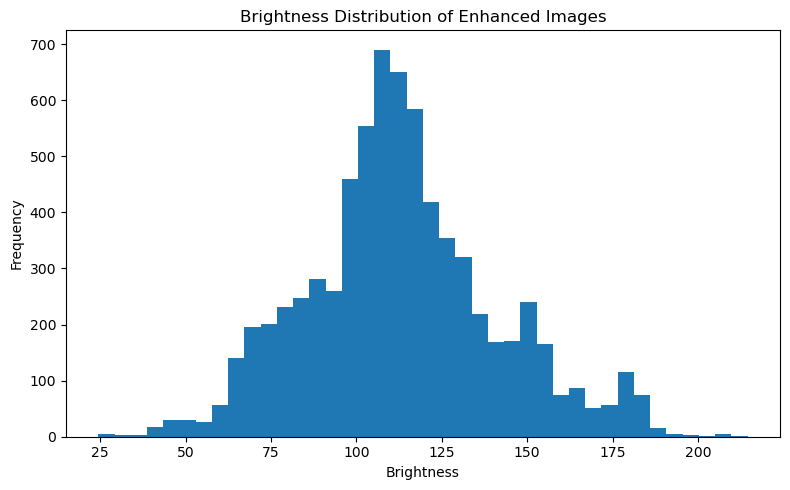

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df["brightness"],
    bins=40
)

plt.xlabel("Brightness")

plt.ylabel("Frequency")

plt.title(
    "Brightness Distribution of Enhanced Images"
)

plt.tight_layout()

plt.show()

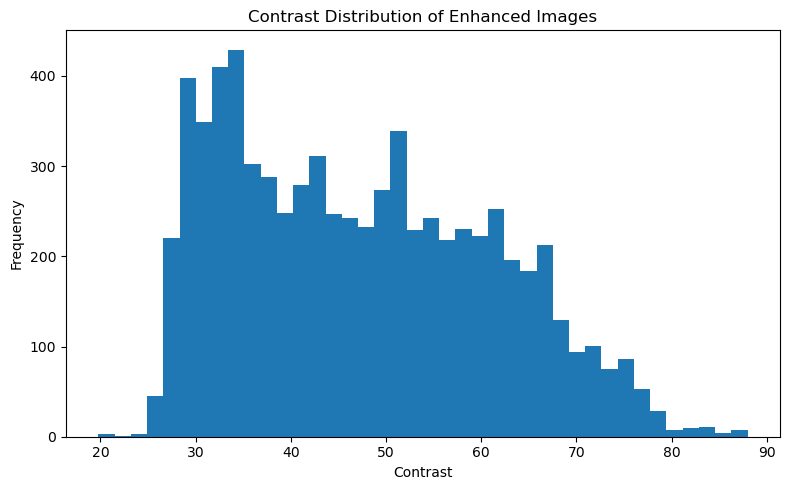

In [4]:
plt.figure(figsize=(8,5))

plt.hist(
    df["contrast"],
    bins=40
)

plt.xlabel("Contrast")

plt.ylabel("Frequency")

plt.title(
    "Contrast Distribution of Enhanced Images"
)

plt.tight_layout()

plt.show()

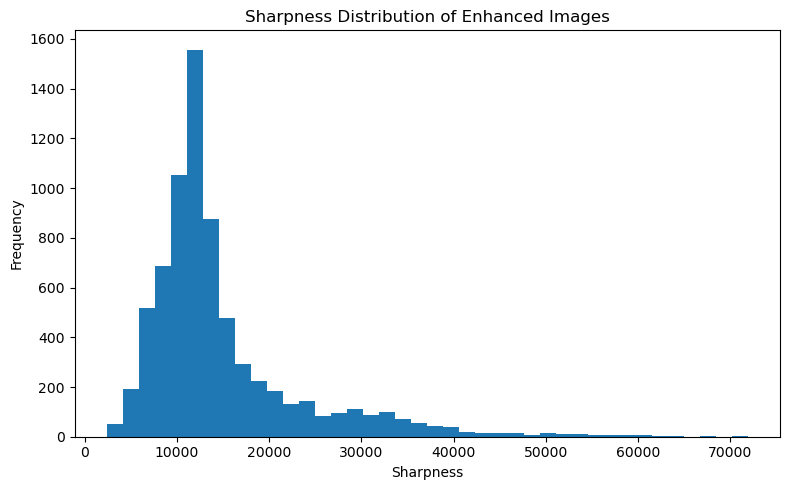

In [5]:
plt.figure(figsize=(8,5))

plt.hist(
    df["sharpness"],
    bins=40
)

plt.xlabel("Sharpness")

plt.ylabel("Frequency")

plt.title(
    "Sharpness Distribution of Enhanced Images"
)

plt.tight_layout()

plt.show()

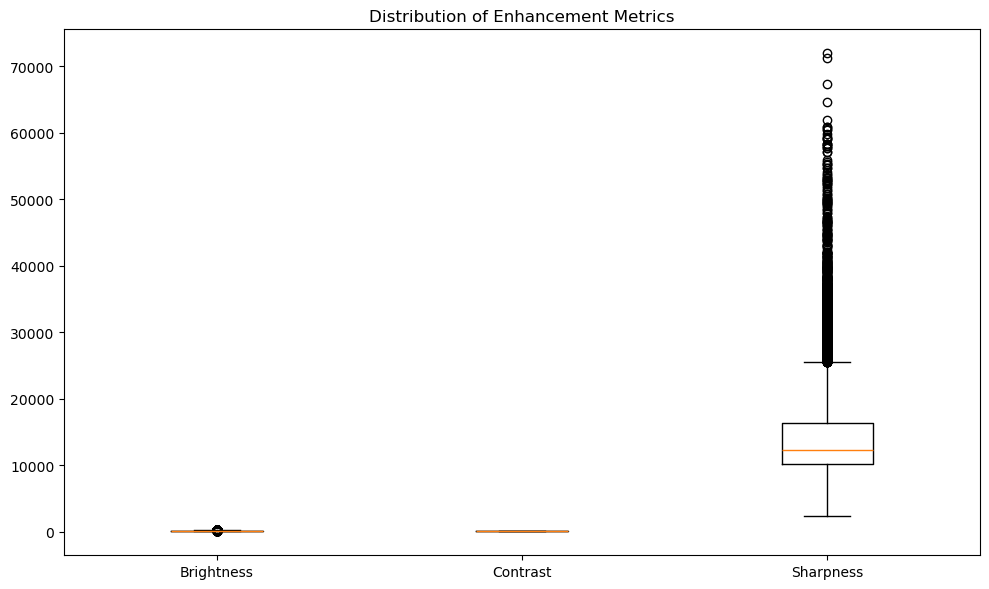

In [6]:
plt.figure(figsize=(10,6))

plt.boxplot([
    df["brightness"],
    df["contrast"],
    df["sharpness"]
])

plt.xticks(
    [1,2,3],
    [
        "Brightness",
        "Contrast",
        "Sharpness"
    ]
)

plt.title(
    "Distribution of Enhancement Metrics"
)

plt.tight_layout()

plt.show()

In [7]:
corr = df[
    [
        "brightness",
        "contrast",
        "sharpness"
    ]
].corr()

print(corr)

            brightness  contrast  sharpness
brightness    1.000000 -0.097545  -0.006320
contrast     -0.097545  1.000000   0.552131
sharpness    -0.006320  0.552131   1.000000


In [8]:
summary = df.describe()

summary.to_csv(
    "Results/metrics/summary_statistics.csv"
)

print("Summary Statistics Saved")

Summary Statistics Saved


In [9]:
import json

with open(
    r"E:\PHD Rahul Jain\Underwater\trashcan_data\meta.json",
    "r"
) as f:

    meta = json.load(f)

print(meta)

{'classes': [{'title': 'animal crab', 'shape': 'any', 'color': '#911EB4', 'geometry_config': {}, 'id': 6532742, 'hotkey': ''}, {'title': 'animal eel', 'shape': 'any', 'color': '#46F0F0', 'geometry_config': {}, 'id': 6532743, 'hotkey': ''}, {'title': 'animal etc', 'shape': 'any', 'color': '#F032E6', 'geometry_config': {}, 'id': 6532744, 'hotkey': ''}, {'title': 'animal fish', 'shape': 'any', 'color': '#FFE119', 'geometry_config': {}, 'id': 6532739, 'hotkey': ''}, {'title': 'animal shells', 'shape': 'any', 'color': '#F58230', 'geometry_config': {}, 'id': 6532741, 'hotkey': ''}, {'title': 'animal starfish', 'shape': 'any', 'color': '#0082C8', 'geometry_config': {}, 'id': 6532740, 'hotkey': ''}, {'title': 'plant', 'shape': 'any', 'color': '#3CB44B', 'geometry_config': {}, 'id': 6532738, 'hotkey': ''}, {'title': 'rov', 'shape': 'any', 'color': '#E6194B', 'geometry_config': {}, 'id': 6532737, 'hotkey': ''}, {'title': 'trash branch', 'shape': 'any', 'color': '#FFD7B4', 'geometry_config': {}, 

In [10]:
import os

ann_folder = r"E:\PHD Rahul Jain\Underwater\trashcan_data\instance train\ann"

files = os.listdir(ann_folder)

print("Total annotation files:", len(files))

print("First 5 files:")
print(files[:5])

Total annotation files: 6065
First 5 files:
['vid_000002_frame0000023.jpg.json', 'vid_000003_frame0000007.jpg.json', 'vid_000003_frame0000008.jpg.json', 'vid_000003_frame0000010.jpg.json', 'vid_000003_frame0000011.jpg.json']


In [11]:
import json
from pprint import pprint

sample_file = os.path.join(
    ann_folder,
    files[0]
)

with open(sample_file, "r") as f:
    data = json.load(f)

pprint(data)

{'description': '',
 'objects': [{'classId': 6532745,
              'classTitle': 'trash etc',
              'createdAt': '2024-03-01T12:57:26.722Z',
              'description': '',
              'geometryType': 'polygon',
              'id': 150111185,
              'labelerLogin': 'inbox@datasetninja.com',
              'objectId': None,
              'points': {'exterior': [[225, 264],
                                      [219, 265],
                                      [217, 264],
                                      [217, 259],
                                      [228, 253],
                                      [229, 252],
                                      [228, 248],
                                      [231, 246],
                                      [268, 246],
                                      [275, 256],
                                      [274, 265],
                                      [272, 269],
                                      [230, 269]],
      